In [1]:
import jax.numpy as jnp
import nir
import numpy as np

import spyx

In [2]:
isis = [
    6, 15, 4, 3, 0, 2, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 
    0, 0, 0, 13, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 0, 14
]
d1 = list(np.concatenate([isi*[0]+[1] for isi in isis]))[:100]
d = jnp.array([[e] + 9*[0] for e in d1], dtype=jnp.uint8).reshape(1, -1)

In [3]:
data = jnp.expand_dims(d, -1)

In [4]:
data.shape

(1, 1000, 1)

In [5]:
nir_net = nir.read("./lif_norse.nir")

In [6]:
nir_net.nodes

{'0': Affine(weight=array([[1.]], dtype=float32), bias=array([0.], dtype=float32), input_type={'input': array([1])}, output_type={'output': array([1])}, metadata={}),
 '1': LIF(tau=array([0.0025], dtype=float32), r=array([1.], dtype=float32), v_leak=array([0.], dtype=float32), v_threshold=array([0.1], dtype=float32), v_reset=array([0.], dtype=float32), input_type={'input': array([1])}, output_type={'output': array([1])}, metadata={}),
 'input': Input(input_type={'input': array([1])}, metadata={}),
 'output': Output(output_type={'output': array([1])}, metadata={})}

In [7]:
# return_all_states captures per-timestep neuron state (the membrane trace).
model, (spikes, states) = spyx.nir.from_nir(
    nir_net, data.astype(jnp.float32), dt=1e-4, return_all_states=True
)
spikes.shape

(1, 1000, 1)

In [8]:
# `states` mirrors the per-layer initial_state; stateless layers (e.g. the
# input Linear) are None. Grab the LIF's membrane trace (the first stateful one).
voltage_trace = next(s for s in states if s is not None)

In [9]:
voltage_trace[0].flatten()[60:70]

Array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

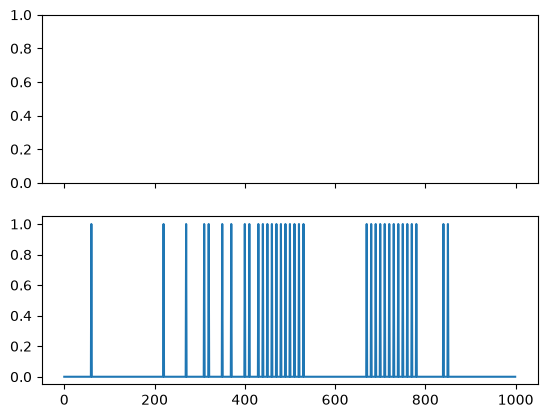

In [10]:
import matplotlib.pyplot as plt

spk, mem = spikes.flatten(), voltage_trace[0].flatten()

fig, axs = plt.subplots(2, 1, sharex=True)
axs[0].eventplot(np.where(spk == 1))
axs[1].plot(mem)
plt.show();

In [11]:
with open('lif_spyx.csv', 'w') as fw:
    for idx in range(d.shape[1]):
        fw.write(f'{d[0,idx]},{mem[idx]},{spk[idx]}\n')

In [12]:
# Re-export the reconstructed model back to NIR.
spyx.nir.to_nir(model, {"input": (1,)}, {"output": (1,)}, dt=1e-4)

NIRGraph(nodes={'input': Input(input_type={'input': (1,)}, metadata={}), 'output': Output(output_type={'output': (1,)}, metadata={}), 'layer_0': Affine(weight=array([[1.]], dtype=float32), bias=array([0.], dtype=float32), input_type={'input': array([1])}, output_type={'output': array([1])}, metadata={}), 'layer_1': LIF(tau=array([0.0025], dtype=float32), r=array([0.96], dtype=float32), v_leak=array([0.], dtype=float32), v_threshold=array([0.1], dtype=float32), v_reset=array([0.], dtype=float32), input_type={'input': array([1])}, output_type={'output': array([1])}, metadata={})}, edges=[('input', 'layer_0'), ('layer_0', 'layer_1'), ('layer_1', 'output')], input_type={'input': (1,)}, output_type={'output': (1,)}, metadata={})